# Diabetes Readmission - distribuciones de variables

Carga el dataset `diabetes_readmission` de TableShift con el mismo patron de `test.ipynb` y define funciones para visualizar distribuciones numericas y categoricas.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tableshift import get_dataset
from tableshift.core.features import PreprocessorConfig

c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\xport\__about__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
def find_project_root(start=Path.cwd()):
    """Return the repository root that contains pyproject.toml and data/."""
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "data").exists():
            return path
    raise RuntimeError("No se encontro la raiz del repo")


PROJECT_ROOT = find_project_root()
CACHE_DIR = PROJECT_ROOT / "data" / "raw" / "tableshift_cache"

print(f"Project root: {PROJECT_ROOT}" f"\nCache dir: {CACHE_DIR}")

Project root: c:\Users\jeffr\GitHub\tesis-darl
Cache dir: c:\Users\jeffr\GitHub\tesis-darl\data\raw\tableshift_cache


In [3]:
def passthrough_preprocessor() -> PreprocessorConfig:
    """Return a PreprocessorConfig that skips TableShift transformations."""
    return PreprocessorConfig(
        categorical_features="passthrough",
        numeric_features="passthrough",
        dropna="all",
    )

In [4]:
DATASET_NAME = "diabetes_readmission"

dset = get_dataset(
    DATASET_NAME,
    cache_dir=str(CACHE_DIR),
    preprocessor_config=passthrough_preprocessor(),
)

print(dset)

c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(
c:\Users\jeffr\GitHub\tesis-darl\.venv\Lib\site-packages\sklearn\compose\_column_transformer.py:1590: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  df_row = df_row.select_dtypes(


TabularDataset(name='diabetes_readmission', preprocessor_config=PreprocessorConfig(categorical_features='passthrough', numeric_features='passthrough', domain_labels='label_encode', passthrough_columns=None, dropna='all', use_extended_names=False, map_targets=False, cast_targets_to_default_type=False, min_frequency=None, max_categories=None, n_bins=5, sub_illegal_chars=True), config=DatasetConfig(cache_dir='c:\\Users\\jeffr\\GitHub\\tesis-darl\\data\\raw\\tableshift_cache', download=True, random_seed=948324), initialize_data=True, splitter=DomainSplitter(val_size=0.1, random_state=264738, id_test_size=0.1, domain_split_varname='admission_source_id', domain_split_ood_values=[7], domain_split_id_values=None, domain_split_gt_thresh=None, drop_domain_split_col=True, ood_val_size=0.1), grouper=Grouper(features_and_values={'race': ['Caucasian'], 'gender': ['Male']}, drop=False, transformer=None), feature_names=['troglitazone', 'gender', 'max_glu_serum', 'acetohexamide', 'change', 'diabetesMed

In [5]:
X_train, y_train, g_train, _ = dset.get_pandas(split="train")
X_val, y_val, g_val, _ = dset.get_pandas(split="validation")
X_id_test, y_id_test, g_id_test, _ = dset.get_pandas(split="id_test")
X_ood, y_ood, g_ood, _ = dset.get_pandas(split="ood_test")

splits = {
    "train": (X_train, y_train),
    "validation": (X_val, y_val),
    "id_test": (X_id_test, y_id_test),
    "ood_test": (X_ood, y_ood),
}

for split_name, (X_split, y_split) in splits.items():
    print(f"{split_name:10s} X={X_split.shape} y={y_split.shape}")

train      X=(34288, 46) y=(34288,)
validation X=(4286, 46) y=(4286,)
id_test    X=(4287, 46) y=(4287,)
ood_test   X=(50968, 46) y=(50968,)


In [6]:
def split_feature_types(df: pd.DataFrame, cardinality_threshold: int = 20):
    """Separate continuous numeric, ordinal numeric, and categorical columns."""
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    continuous_cols = [
        col
        for col in numeric_cols
        if df[col].nunique(dropna=True) > cardinality_threshold
    ]
    ordinal_cols = [
        col
        for col in numeric_cols
        if df[col].nunique(dropna=True) <= cardinality_threshold
    ]

    return continuous_cols, ordinal_cols, categorical_cols


continuous_cols, ordinal_cols, categorical_cols = split_feature_types(X_train)

print(f"Continuas numericas ({len(continuous_cols)}):")

for col in continuous_cols:
    print(f"  - {col}")

print(f"Ordinales numericas ({len(ordinal_cols)}):")
for col in ordinal_cols:
    print(f"  - {col}")

print(f"Categoricas ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")

Continuas numericas (4):
  - discharge_disposition_id
  - num_lab_procedures
  - num_medications
  - number_outpatient
Ordinales numericas (8):
  - race
  - gender
  - admission_type_id
  - time_in_hospital
  - num_procedures
  - number_emergency
  - number_inpatient
  - number_diagnoses
Categoricas (34):
  - age
  - weight
  - payer_code
  - medical_specialty
  - diag_1
  - diag_2
  - diag_3
  - max_glu_serum
  - A1Cresult
  - metformin
  - repaglinide
  - nateglinide
  - chlorpropamide
  - glimepiride
  - acetohexamide
  - glipizide
  - glyburide
  - tolbutamide
  - pioglitazone
  - rosiglitazone
  - acarbose
  - miglitol
  - troglitazone
  - tolazamide
  - examide
  - citoglipton
  - insulin
  - glyburide-metformin
  - glipizide-metformin
  - glimepiride-pioglitazone
  - metformin-rosiglitazone
  - metformin-pioglitazone
  - change
  - diabetesMed


In [7]:
def plot_numeric_distributions(
    df: pd.DataFrame,
    columns: list[str] | None = None,
    bins: int = 30,
    max_cols: int = 3,
    figsize_per_plot: tuple[float, float] = (4.5, 3.0),
):
    """Plot histograms for numeric variables in a DataFrame."""
    if columns is None:
        columns = df.select_dtypes(include="number").columns.tolist()

    columns = [col for col in columns if col in df.columns]
    if not columns:
        raise ValueError("No hay columnas numericas para plotear")

    n_cols = min(max_cols, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows),
        squeeze=False,
    )

    for ax, col in zip(axes.ravel(), columns):
        values = df[col].dropna()
        ax.hist(values, bins=bins, color="#3b82f6", edgecolor="white", alpha=0.85)
        ax.set_title(col)
        ax.set_ylabel("Frecuencia")
        ax.grid(axis="y", alpha=0.25)

    for ax in axes.ravel()[len(columns) :]:
        ax.set_visible(False)

    fig.tight_layout()
    return fig, axes

In [8]:
def plot_categorical_distributions(
    df: pd.DataFrame,
    columns: list[str] | None = None,
    top_n: int = 15,
    max_cols: int = 2,
    figsize_per_plot: tuple[float, float] = (6.0, 3.5),
):
    """Plot bar charts for categorical or low-cardinality variables."""
    if columns is None:
        columns = df.select_dtypes(
            include=["object", "category", "bool"]
        ).columns.tolist()

    columns = [col for col in columns if col in df.columns]
    if not columns:
        raise ValueError("No hay columnas categoricas para plotear")

    n_cols = min(max_cols, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows),
        squeeze=False,
    )

    for ax, col in zip(axes.ravel(), columns):
        counts = df[col].astype("string").fillna("<NA>").value_counts().head(top_n)
        ax.bar(counts.index, counts.values, color="#10b981", alpha=0.9)
        ax.set_title(col)
        ax.set_ylabel("Frecuencia")
        ax.tick_params(axis="x", labelrotation=45)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")
        ax.grid(axis="y", alpha=0.25)

    for ax in axes.ravel()[len(columns) :]:
        ax.set_visible(False)

    fig.tight_layout()
    return fig, axes

In [9]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numeric_cols: list[str] | None = None,
    categorical_cols: list[str] | None = None,
    ordinal_as_categorical: bool = True,
    cardinality_threshold: int = 20,
):
    """Plot numeric and categorical distributions for a TableShift split."""
    continuous, ordinal, inferred_categorical = split_feature_types(
        df,
        cardinality_threshold=cardinality_threshold,
    )

    if numeric_cols is None:
        numeric_cols = continuous if ordinal_as_categorical else continuous + ordinal
    if categorical_cols is None:
        categorical_cols = inferred_categorical + (
            ordinal if ordinal_as_categorical else []
        )

    figures = {}
    if numeric_cols:
        figures["numeric"] = plot_numeric_distributions(df, numeric_cols)
    if categorical_cols:
        figures["categorical"] = plot_categorical_distributions(df, categorical_cols)

    return figures

## Ejemplos de uso

Ejecuta las celdas siguientes para visualizar el split de entrenamiento. Ajusta `top_n`, `bins` o las listas de columnas si quieres revisar subconjuntos concretos.


(<Figure size 1350x600 with 6 Axes>,
 array([[<Axes: title={'center': 'discharge_disposition_id'}, ylabel='Frecuencia'>,
         <Axes: title={'center': 'num_lab_procedures'}, ylabel='Frecuencia'>,
         <Axes: title={'center': 'num_medications'}, ylabel='Frecuencia'>],
        [<Axes: title={'center': 'number_outpatient'}, ylabel='Frecuencia'>,
         <Axes: >, <Axes: >]], dtype=object))

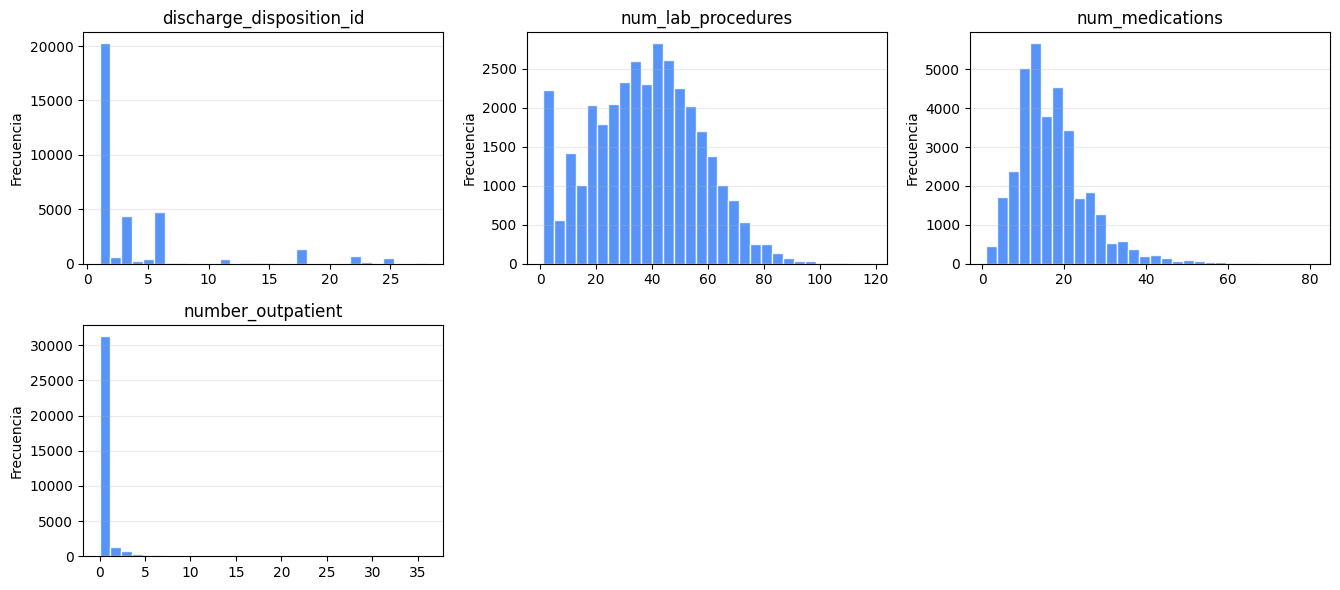

In [ ]:
plot_numeric_distributions(X_train, continuous_cols, bins=30)

In [ ]:
plot_categorical_distributions(X_train, categorical_cols + ordinal_cols, top_n=15)

In [ ]:
# Funcion combinada para cualquier split cargado:
# figures = plot_feature_distributions(X_ood)

## Variables clinicas y administrativas destacadas

Esta seccion concentra las variables mas utiles para interpretar riesgo de readmision y posibles cambios de distribucion: estancia hospitalaria, intensidad de atencion, historial de uso del sistema, diagnosticos, HbA1c, medicacion, demografia y contexto de admision/alta.


In [10]:
SIGNIFICANT_NUMERIC_VARIABLES = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

SIGNIFICANT_CATEGORICAL_VARIABLES = [
    "readmitted",
    "A1Cresult",
    "diag_1",
    "diag_2",
    "diag_3",
    "admission_type_id",
    "admission_source_id",
    "discharge_disposition_id",
    "age",
    "gender",
    "race",
    "change",
    "diabetesMed",
    "insulin",
    "metformin",
]


def available_columns(df: pd.DataFrame, columns: list[str]) -> list[str]:
    """Return requested columns that are present in the DataFrame."""
    return [column for column in columns if column in df.columns]


def missing_columns(df: pd.DataFrame, columns: list[str]) -> list[str]:
    """Return requested columns that are not present in the DataFrame."""
    return [column for column in columns if column not in df.columns]


significant_numeric_cols = available_columns(X_train, SIGNIFICANT_NUMERIC_VARIABLES)
significant_categorical_cols = available_columns(
    X_train, SIGNIFICANT_CATEGORICAL_VARIABLES
)

print(
    f"Numericas disponibles ({len(significant_numeric_cols)}): {significant_numeric_cols}"
)
print(
    f"Categoricas disponibles ({len(significant_categorical_cols)}): {significant_categorical_cols}"
)

missing_significant_cols = missing_columns(
    X_train,
    SIGNIFICANT_NUMERIC_VARIABLES + SIGNIFICANT_CATEGORICAL_VARIABLES,
)
if missing_significant_cols:
    print(
        f"No disponibles en X_train ({len(missing_significant_cols)}): {missing_significant_cols}"
    )

Numericas disponibles (8): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Categoricas disponibles (13): ['A1Cresult', 'diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'age', 'gender', 'race', 'change', 'diabetesMed', 'insulin', 'metformin']
No disponibles en X_train (2): ['readmitted', 'admission_source_id']


In [12]:
def plot_frequency_table(
    series: pd.Series,
    title: str,
    top_n: int = 15,
    ax=None,
):
    """Plot absolute and relative frequency for a single variable."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    counts = series.astype("string").fillna("<NA>").value_counts().head(top_n)
    percentages = counts / counts.sum() * 100

    ax.bar(counts.index, counts.values, color="#0f766e", alpha=0.9)
    ax.set_title(title)
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", labelrotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, counts.max() * 1.15 if counts.max() > 0 else 1)

    for patch, pct in zip(ax.patches, percentages):
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height(),
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    return ax

In [13]:
def plot_significant_variable_distributions(
    df: pd.DataFrame,
    y: pd.Series | None = None,
    numeric_cols: list[str] | None = None,
    categorical_cols: list[str] | None = None,
    bins: int = 30,
    top_n: int = 15,
):
    """Plot distributions and frequencies for selected clinical variables."""
    numeric_cols = available_columns(
        df,
        numeric_cols or SIGNIFICANT_NUMERIC_VARIABLES,
    )
    categorical_cols = available_columns(
        df,
        categorical_cols or SIGNIFICANT_CATEGORICAL_VARIABLES,
    )

    if y is not None and "readmitted" in SIGNIFICANT_CATEGORICAL_VARIABLES:
        y_name = y.name or "readmitted"
        df = df.copy()
        df[y_name] = y
        if y_name not in categorical_cols:
            categorical_cols = [y_name, *categorical_cols]

    figures = {}
    if numeric_cols:
        figures["numeric"] = plot_numeric_distributions(
            df,
            numeric_cols,
            bins=bins,
            max_cols=2,
            figsize_per_plot=(5.5, 3.2),
        )
    if categorical_cols:
        figures["categorical"] = plot_categorical_distributions(
            df,
            categorical_cols,
            top_n=top_n,
            max_cols=2,
            figsize_per_plot=(6.2, 3.8),
        )

    return figures

{'numeric': (<Figure size 1100x1280 with 8 Axes>,
  array([[<Axes: title={'center': 'time_in_hospital'}, ylabel='Frecuencia'>,
          <Axes: title={'center': 'num_lab_procedures'}, ylabel='Frecuencia'>],
         [<Axes: title={'center': 'num_procedures'}, ylabel='Frecuencia'>,
          <Axes: title={'center': 'num_medications'}, ylabel='Frecuencia'>],
         [<Axes: title={'center': 'number_outpatient'}, ylabel='Frecuencia'>,
          <Axes: title={'center': 'number_emergency'}, ylabel='Frecuencia'>],
         [<Axes: title={'center': 'number_inpatient'}, ylabel='Frecuencia'>,
          <Axes: title={'center': 'number_diagnoses'}, ylabel='Frecuencia'>]],
        dtype=object)),
 'categorical': (<Figure size 1240x2660 with 14 Axes>,
  array([[<Axes: title={'center': 'readmitted'}, ylabel='Frecuencia'>,
          <Axes: title={'center': 'A1Cresult'}, ylabel='Frecuencia'>],
         [<Axes: title={'center': 'diag_1'}, ylabel='Frecuencia'>,
          <Axes: title={'center': 'diag_2

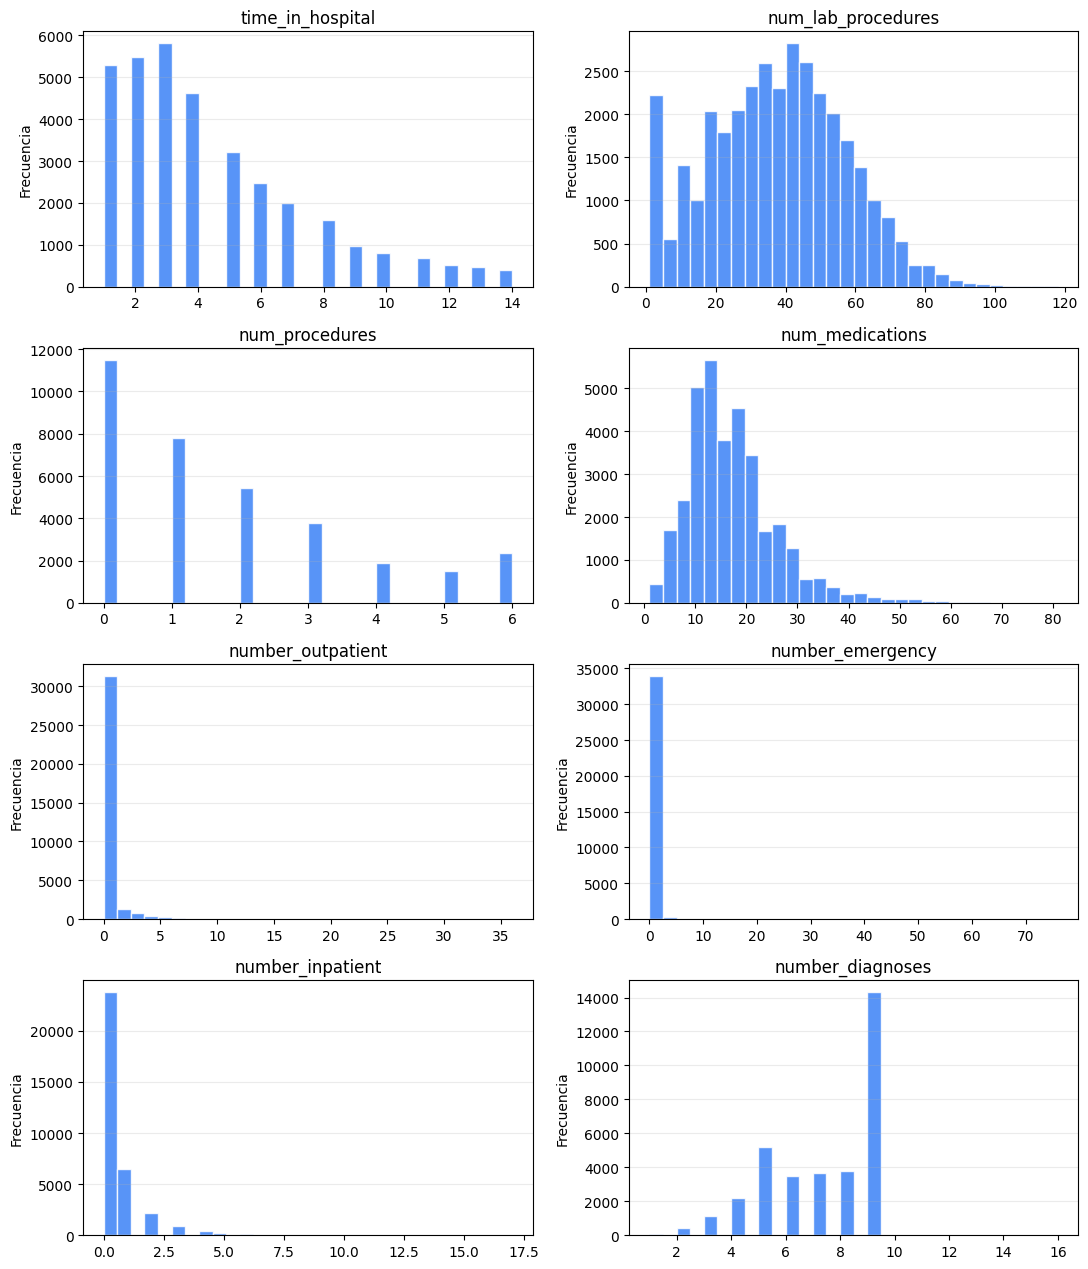

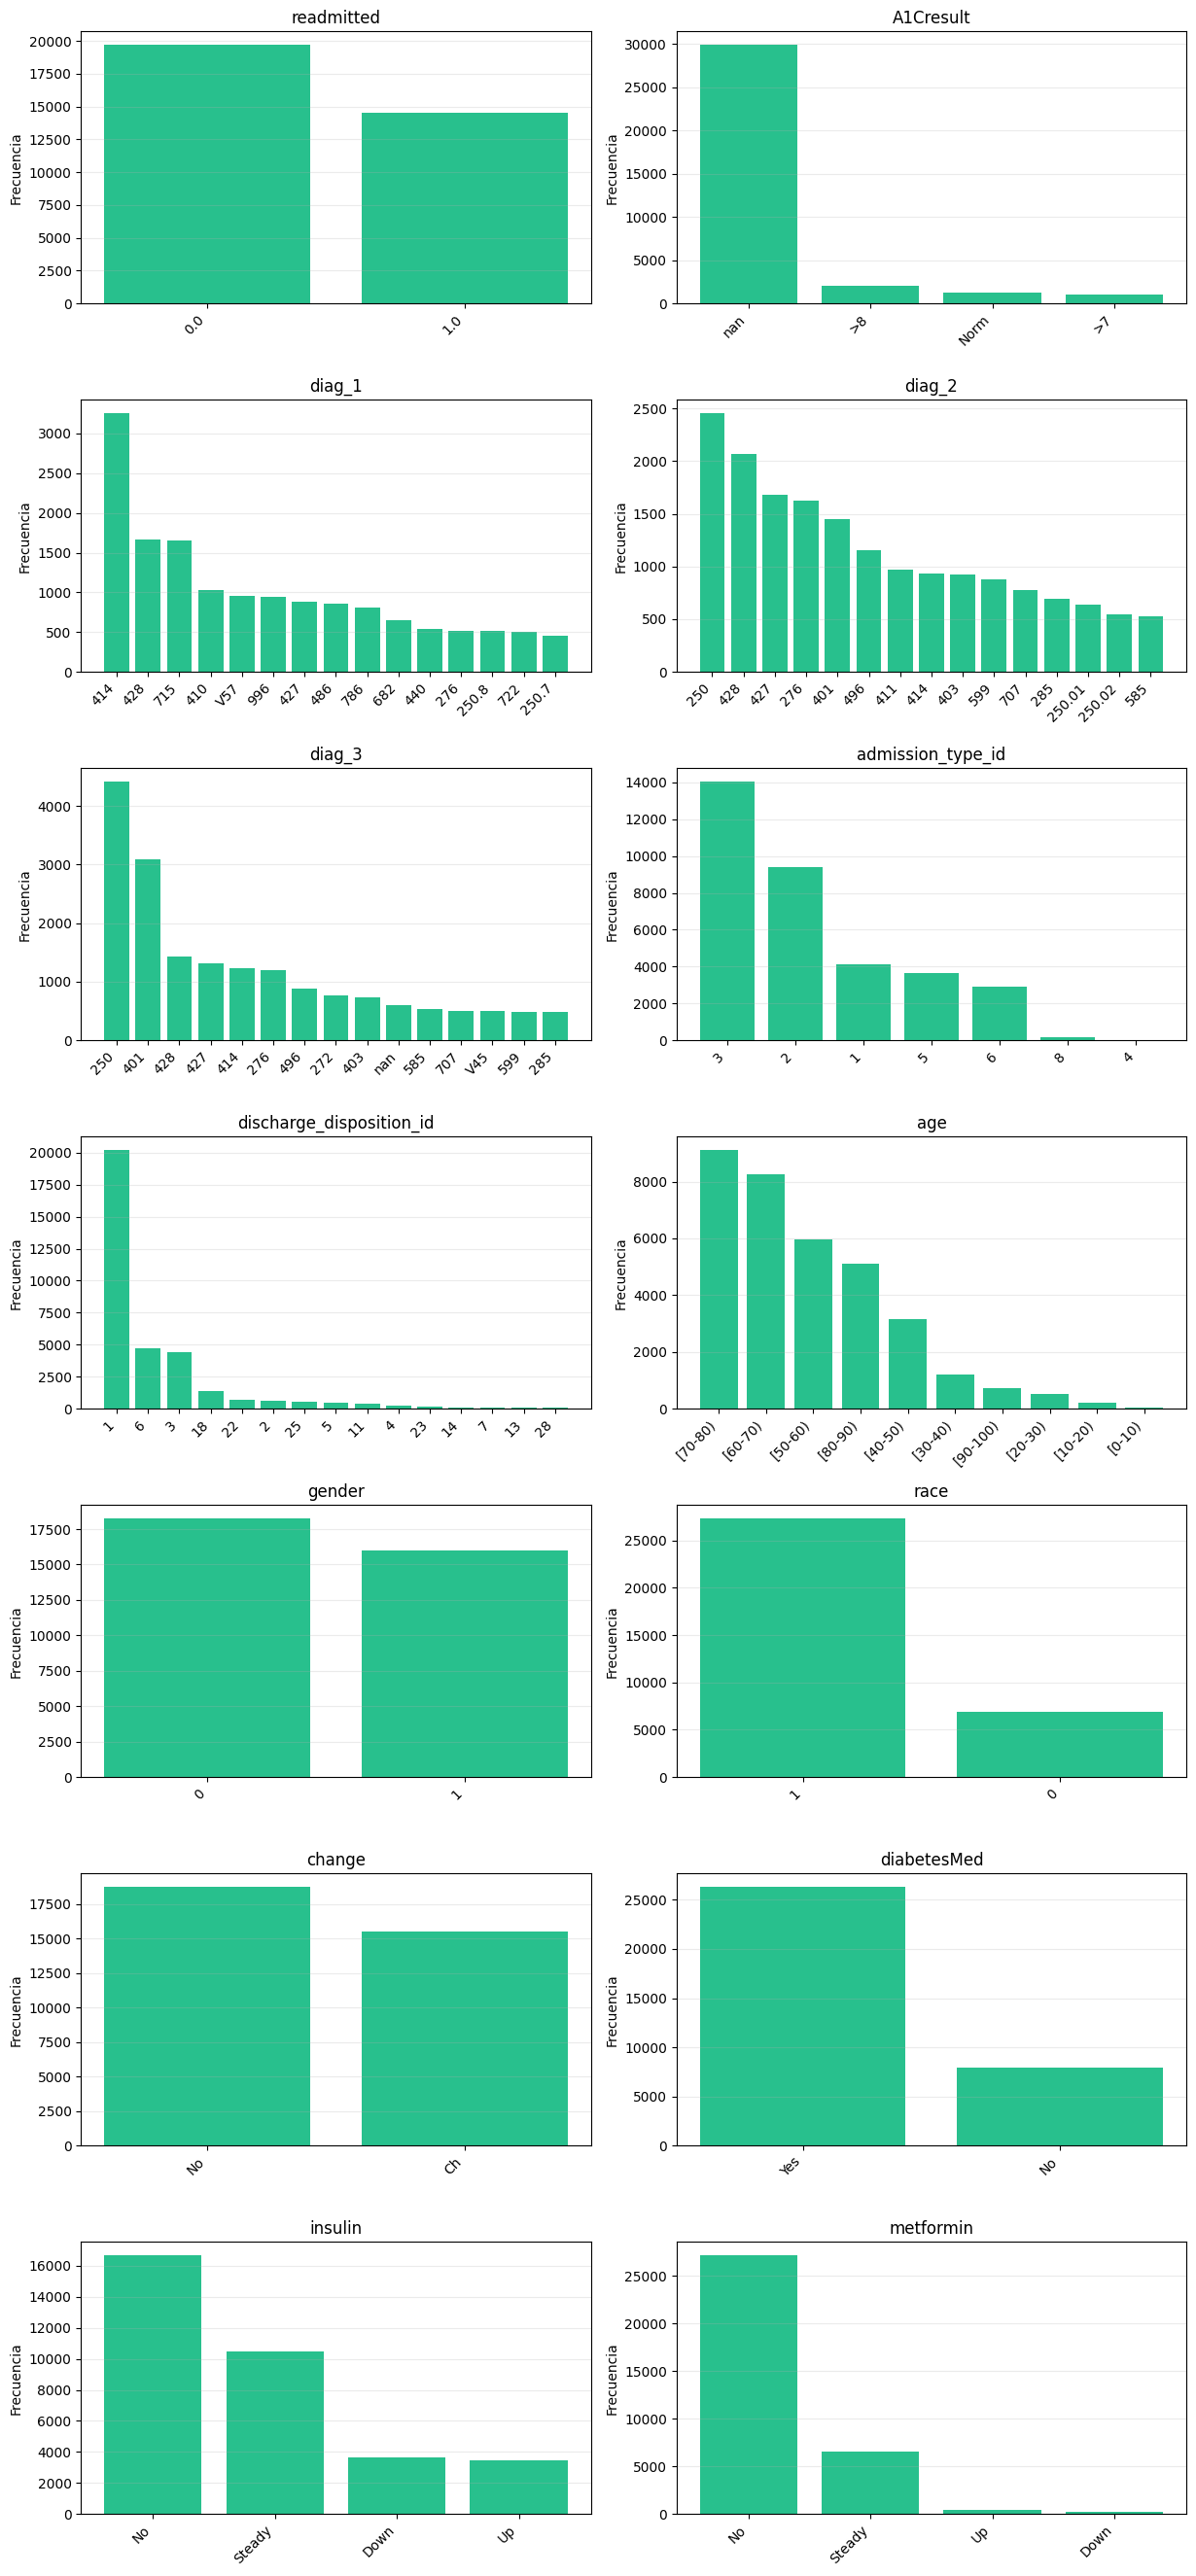

In [ ]:
plot_significant_variable_distributions(
    X_train,
    y=y_train,
    bins=30,
    top_n=15,
)

<Axes: title={'center': 'A1Cresult'}, ylabel='Frecuencia'>

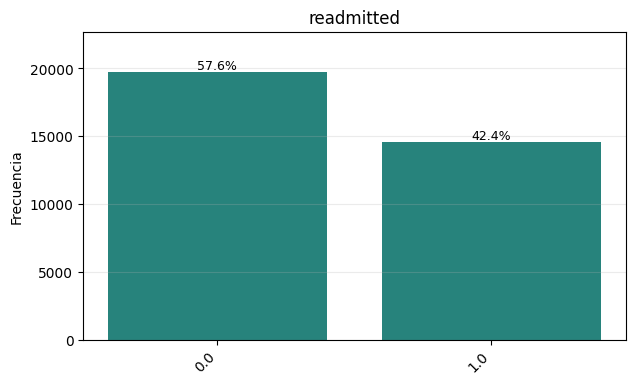

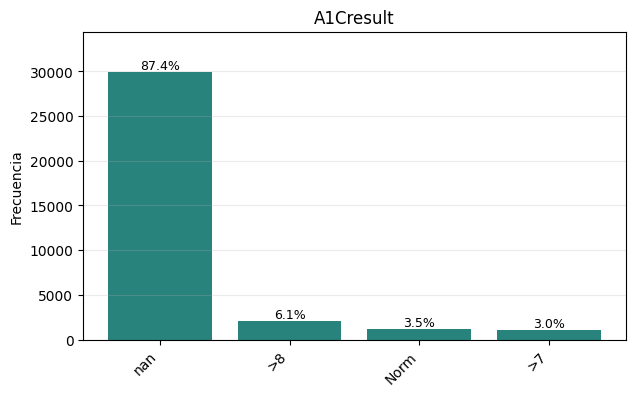

In [15]:
# Frecuencia detallada de una variable especifica:
plot_frequency_table(y_train, title="readmitted", top_n=3)
plot_frequency_table(X_train["A1Cresult"], title="A1Cresult", top_n=10)

## Drift sintético controlado en una variable categórica

En esta sección se toma una variable categórica multiclase, por defecto `diag_1`, se estima su distribución original \(p_0\), se define una distribución objetivo \(q\), se interpola con una severidad \(\alpha\):

\[
p\_{\alpha}=(1-\alpha)p_0+\alpha q
\]

y luego se genera un nuevo batch con drift mediante **remuestreo de filas**. Esto cambia la frecuencia de la categoría sin inventar combinaciones artificiales entre diagnóstico, medicamentos, edad, etc.


In [ ]:
from IPython.display import display

VARIABLE = "diag_1"
TOP_N = 15
ALPHA = 0.35  # 0 = sin drift, 1 = distribución objetivo q completa
RANDOM_STATE = 42

# Distribución objetivo q definida con multiplicadores sobre p0.
# Categorías no listadas conservan multiplicador 1.0.
# Puedes cambiar estos valores para simular otro escenario clínico.
Q_MULTIPLIERS = {
    "414": 0.45,  # reduce el diagnóstico dominante
    "428": 1.80,  # aumenta este diagnóstico
    "V57": 2.20,  # aumenta este diagnóstico
    "410": 1.25,  # aumento moderado
}

assert VARIABLE in X_train.columns, f"{VARIABLE} no existe en X_train"
print(f"Variable seleccionada: {VARIABLE}")
print(f"Severidad alpha: {ALPHA}")

Variable seleccionada: diag_1
Severidad alpha: 0.35


In [ ]:
def categorical_distribution(series: pd.Series) -> pd.Series:
    """Return empirical categorical probabilities, including missing values as '<NA>'."""
    return (
        series.astype("string")
        .fillna("<NA>")
        .value_counts(normalize=True, dropna=False)
        .sort_values(ascending=False)
    )


def build_q_with_multipliers(
    p0: pd.Series,
    multipliers: dict[str, float] | None = None,
) -> pd.Series:
    """
    Build a target distribution q by multiplying selected category probabilities.

    Example:
        p0['414'] is large.
        multiplier {'414': 0.5} reduces its relative mass in q.
        multiplier {'428': 2.0} increases its relative mass in q.

    The result is normalized so q sums to 1.
    """
    multipliers = multipliers or {}
    q = p0.copy().astype(float)

    for category, multiplier in multipliers.items():
        if category not in q.index:
            print(f"[Aviso] Categoria {category!r} no encontrada en p0; se ignora.")
            continue
        if multiplier < 0:
            raise ValueError("Los multiplicadores deben ser >= 0")
        q.loc[category] *= multiplier

    if q.sum() <= 0:
        raise ValueError("q no puede sumar 0. Revisa los multiplicadores.")

    return q / q.sum()


def build_uniform_q(p0: pd.Series) -> pd.Series:
    """Alternative target q: uniform distribution over observed categories."""
    return pd.Series(
        np.ones(len(p0)) / len(p0),
        index=p0.index,
        name="q_uniform",
    )


def interpolate_distribution(
    p0: pd.Series,
    q: pd.Series,
    alpha: float,
) -> pd.Series:
    """Compute p_alpha = (1-alpha) p0 + alpha q."""
    if not 0 <= alpha <= 1:
        raise ValueError("alpha debe estar entre 0 y 1")

    categories = p0.index.union(q.index)
    p0_aligned = p0.reindex(categories, fill_value=0).astype(float)
    q_aligned = q.reindex(categories, fill_value=0).astype(float)

    p_alpha = (1 - alpha) * p0_aligned + alpha * q_aligned
    p_alpha = p_alpha / p_alpha.sum()
    p_alpha.name = f"p_alpha_{alpha:.2f}"
    return p_alpha.sort_values(ascending=False)


def sample_rows_with_categorical_drift(
    df: pd.DataFrame,
    column: str,
    target_p: pd.Series,
    reference_p: pd.Series | None = None,
    n: int | None = None,
    replace: bool = True,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Create a drifted batch by resampling rows with weights target_p / reference_p.

    This preserves realistic row-level combinations because it does not rewrite the category.
    It only changes which existing rows appear more often.
    """
    if column not in df.columns:
        raise KeyError(f"{column} no existe en df")

    if reference_p is None:
        reference_p = categorical_distribution(df[column])

    n = n or len(df)

    current_categories = df[column].astype("string").fillna("<NA>")
    categories = reference_p.index.union(target_p.index)

    reference = reference_p.reindex(categories, fill_value=0).astype(float)
    target = target_p.reindex(categories, fill_value=0).astype(float)

    ratio = target / reference.replace(0, np.nan)
    ratio = ratio.replace([np.inf, -np.inf], np.nan).fillna(0)

    weights = current_categories.map(ratio).astype(float)

    if weights.sum() <= 0:
        raise ValueError(
            "Los pesos de muestreo suman 0. Revisa target_p y reference_p."
        )

    drifted_df = df.sample(
        n=n,
        replace=replace,
        weights=weights,
        random_state=random_state,
    ).copy()

    return drifted_df


def compare_distributions(
    p0: pd.Series,
    q: pd.Series,
    p_alpha: pd.Series,
    p_after: pd.Series | None = None,
    top_n: int = 20,
) -> pd.DataFrame:
    """Build a comparison table of original, target, interpolated and sampled distributions."""
    categories = p0.index.union(q.index).union(p_alpha.index)
    if p_after is not None:
        categories = categories.union(p_after.index)

    table = pd.DataFrame(
        {
            "p0_original": p0.reindex(categories, fill_value=0),
            "q_objetivo": q.reindex(categories, fill_value=0),
            "p_alpha_teorico": p_alpha.reindex(categories, fill_value=0),
        }
    )

    if p_after is not None:
        table["p_after_muestra"] = p_after.reindex(categories, fill_value=0)
        table["error_muestra_vs_teorico"] = (
            table["p_after_muestra"] - table["p_alpha_teorico"]
        )

    table["delta_teorico_vs_original"] = table["p_alpha_teorico"] - table["p0_original"]

    return (
        table.sort_values("p0_original", ascending=False)
        .head(top_n)
        .style.format("{:.4f}")
    )


def jensen_shannon_divergence(p: pd.Series, q: pd.Series, eps: float = 1e-12) -> float:
    """Jensen-Shannon divergence between two categorical distributions."""
    categories = p.index.union(q.index)
    p = p.reindex(categories, fill_value=0).astype(float).to_numpy()
    q = q.reindex(categories, fill_value=0).astype(float).to_numpy()

    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)

    kl_pm = np.sum(p * np.log(p / m))
    kl_qm = np.sum(q * np.log(q / m))
    return float(0.5 * (kl_pm + kl_qm))


def population_stability_index(p: pd.Series, q: pd.Series, eps: float = 1e-6) -> float:
    """PSI for categorical distributions."""
    categories = p.index.union(q.index)
    p = p.reindex(categories, fill_value=0).astype(float)
    q = q.reindex(categories, fill_value=0).astype(float)

    p = p.clip(lower=eps)
    q = q.clip(lower=eps)

    return float(((q - p) * np.log(q / p)).sum())

In [ ]:
def plot_single_categorical_distribution(
    series: pd.Series,
    title: str,
    top_n: int = 15,
    relative: bool = False,
    ax=None,
):
    """Plot one categorical variable distribution."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4.5))

    counts = series.astype("string").fillna("<NA>").value_counts().head(top_n)

    if relative:
        values = counts / len(series) * 100
        xlabel = "Porcentaje (%)"
    else:
        values = counts
        xlabel = "Frecuencia"

    ax.bar(values.index, values.values, alpha=0.9)
    ax.set_title(title)
    ax.set_ylabel(xlabel)
    ax.tick_params(axis="x", labelrotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, values.max() * 1.15 if values.max() > 0 else 1)

    for patch, value in zip(ax.patches, values.values):
        label = f"{value:.1f}%" if relative else f"{int(value)}"
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height(),
            label,
            ha="center",
            va="bottom",
            fontsize=9,
        )

    return ax


def plot_before_after_categorical(
    before: pd.Series,
    after: pd.Series,
    column: str,
    top_n: int = 15,
    relative: bool = True,
):
    """Plot before and after distributions side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

    plot_single_categorical_distribution(
        before,
        title=f"Antes: {column}",
        top_n=top_n,
        relative=relative,
        ax=axes[0],
    )

    plot_single_categorical_distribution(
        after,
        title=f"Después con drift: {column}",
        top_n=top_n,
        relative=relative,
        ax=axes[1],
    )

    plt.tight_layout()
    return fig, axes


def plot_overlay_categorical_distributions(
    before: pd.Series,
    after: pd.Series,
    column: str,
    top_n: int = 15,
    relative: bool = True,
    sort_by: str = "max",
):
    """
    Plot before and after distributions in the same vertical grouped bar chart.

    Parameters
    ----------
    before, after:
        Original and drifted categorical series.
    column:
        Feature name used in the chart title.
    top_n:
        Number of categories to show.
    relative:
        If True, plots percentages. If False, plots absolute frequencies.
    sort_by:
        'max' sorts by the largest value between before/after.
        'before' sorts by the original distribution.
        'after' sorts by the drifted distribution.
    """
    before_counts = before.astype("string").fillna("<NA>").value_counts(dropna=False)
    after_counts = after.astype("string").fillna("<NA>").value_counts(dropna=False)

    if relative:
        before_values = before_counts / len(before) * 100
        after_values = after_counts / len(after) * 100
        xlabel = "Porcentaje (%)"
        value_fmt = "{:.1f}%"
    else:
        before_values = before_counts
        after_values = after_counts
        xlabel = "Frecuencia"
        value_fmt = "{:.0f}"

    combined = pd.DataFrame({"Antes": before_values, "Después": after_values}).fillna(0)

    if sort_by == "before":
        combined = combined.sort_values("Antes", ascending=False)
    elif sort_by == "after":
        combined = combined.sort_values("Después", ascending=False)
    elif sort_by == "max":
        combined = combined.assign(_max=combined[["Antes", "Después"]].max(axis=1))
        combined = combined.sort_values("_max", ascending=False).drop(columns="_max")
    else:
        raise ValueError("sort_by debe ser 'max', 'before' o 'after'.")

    combined = combined.head(top_n)

    x = np.arange(len(combined))
    width = 0.38

    fig, ax = plt.subplots(figsize=(max(10, 0.65 * len(combined) + 3), 6))

    ax.bar(
        x - width / 2,
        combined["Antes"].values,
        width=width,
        label="Antes",
        color="#1f77b4",
        alpha=0.85,
    )
    ax.bar(
        x + width / 2,
        combined["Después"].values,
        width=width,
        label="Después con drift",
        color="#ff7f0e",
        alpha=0.85,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(combined.index, rotation=45, ha="right")
    ax.set_ylabel(xlabel)
    ax.set_title(f"Antes vs. después en una sola gráfica: {column}")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

    max_value = combined[["Antes", "Después"]].to_numpy().max()
    offset = max_value * 0.01 if max_value > 0 else 0.01
    ax.set_ylim(0, max_value * 1.15 if max_value > 0 else 1)

    for i, value in enumerate(combined["Antes"].values):
        ax.text(
            i - width / 2,
            value + offset,
            value_fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=8,
        )

    for i, value in enumerate(combined["Después"].values):
        ax.text(
            i + width / 2,
            value + offset,
            value_fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.tight_layout()
    return fig, ax

### 1. Distribución original \(p_0\)

Aquí se estima la distribución empírica original de `diag_1`. Cada barra representa la probabilidad/frecuencia observada de una categoría.


Top categorias de p0:


,p0_original
diag_1,
414,0.095106
428,0.048472
715,0.048209
410,0.030069
V57,0.027794
996,0.027415
427,0.025811
486,0.024848
786,0.023769


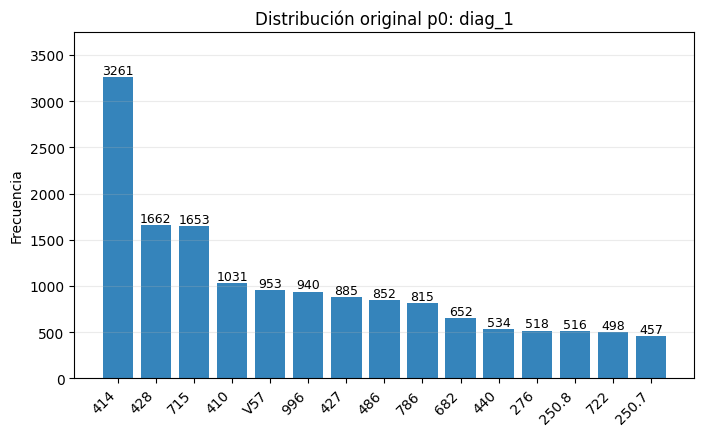

In [19]:
p0 = categorical_distribution(X_train[VARIABLE])

print("Top categorias de p0:")
display(p0.head(TOP_N).to_frame("p0_original"))

plot_single_categorical_distribution(
    X_train[VARIABLE],
    title=f"Distribución original p0: {VARIABLE}",
    top_n=TOP_N,
    relative=False,
)
plt.show()

### 2. Construir \(q\) y aplicar severidad \(\alpha\)

La distribución \(q\) representa el escenario objetivo de drift. Luego `ALPHA` controla qué tan cerca nos movemos desde \(p_0\) hacia \(q\).


In [20]:
# Opción recomendada: q por multiplicadores de categorías específicas.
q = build_q_with_multipliers(p0, Q_MULTIPLIERS)

# Opción alternativa: descomenta esta línea si quieres que q sea uniforme.
# q = build_uniform_q(p0)

p_alpha = interpolate_distribution(p0, q, ALPHA)

print(f"Suma p0      = {p0.sum():.4f}")
print(f"Suma q       = {q.sum():.4f}")
print(f"Suma p_alpha = {p_alpha.sum():.4f}")

display(compare_distributions(p0, q, p_alpha, top_n=TOP_N))

print("Severidad teórica:")
print(f"Jensen-Shannon(p0, p_alpha): {jensen_shannon_divergence(p0, p_alpha):.6f}")
print(f"PSI(p0, p_alpha):            {population_stability_index(p0, p_alpha):.6f}")

Suma p0      = 1.0000
Suma q       = 1.0000
Suma p_alpha = 1.0000


,p0_original,q_objetivo,p_alpha_teorico,delta_teorico_vs_original
diag_1,,,,
414,0.0951,0.0417,0.0764,-0.0187
428,0.0485,0.0849,0.0612,0.0128
715,0.0482,0.0469,0.0478,-0.0004
410,0.0301,0.0366,0.0323,0.0023
V57,0.0278,0.0595,0.0389,0.0111
996,0.0274,0.0267,0.0272,-0.0003
427,0.0258,0.0251,0.0256,-0.0002
486,0.0248,0.0242,0.0246,-0.0002
786,0.0238,0.0231,0.0235,-0.0002


Severidad teórica:
Jensen-Shannon(p0, p_alpha): 0.001377
PSI(p0, p_alpha):            0.011047


### 3. Generar el batch con drift

Se remuestrean filas usando pesos proporcionales a \(p\_{\alpha}(c) / p_0(c)\). Así, las categorías con mayor probabilidad objetivo aparecen más, y las de menor probabilidad objetivo aparecen menos.


In [21]:
X_train_drift = sample_rows_with_categorical_drift(
    X_train,
    column=VARIABLE,
    target_p=p_alpha,
    reference_p=p0,
    n=len(X_train),
    replace=True,
    random_state=RANDOM_STATE,
)

p_after = categorical_distribution(X_train_drift[VARIABLE])

print(f"Shape original: {X_train.shape}")
print(f"Shape drifted:  {X_train_drift.shape}")

display(compare_distributions(p0, q, p_alpha, p_after=p_after, top_n=TOP_N))

print("Drift observado en la muestra:")
print(
    f"Jensen-Shannon(p0, p_after):       {jensen_shannon_divergence(p0, p_after):.6f}"
)
print(
    f"PSI(p0, p_after):                  {population_stability_index(p0, p_after):.6f}"
)
print(
    f"Jensen-Shannon(p_alpha, p_after):  {jensen_shannon_divergence(p_alpha, p_after):.6f}"
)

Shape original: (34288, 46)
Shape drifted:  (34288, 46)


,p0_original,q_objetivo,p_alpha_teorico,p_after_muestra,error_muestra_vs_teorico,delta_teorico_vs_original
diag_1,,,,,,
414,0.0951,0.0417,0.0764,0.0752,-0.0012,-0.0187
428,0.0485,0.0849,0.0612,0.0622,0.0009,0.0128
715,0.0482,0.0469,0.0478,0.0484,0.0006,-0.0004
410,0.0301,0.0366,0.0323,0.0332,0.0009,0.0023
V57,0.0278,0.0595,0.0389,0.0400,0.0011,0.0111
996,0.0274,0.0267,0.0272,0.0263,-0.0008,-0.0003
427,0.0258,0.0251,0.0256,0.0264,0.0008,-0.0002
486,0.0248,0.0242,0.0246,0.0232,-0.0014,-0.0002
786,0.0238,0.0231,0.0235,0.0232,-0.0004,-0.0002


Drift observado en la muestra:
Jensen-Shannon(p0, p_after):       0.004408
PSI(p0, p_after):                  0.037687
Jensen-Shannon(p_alpha, p_after):  0.002800


### 4. Plot antes vs. después

El plot de la izquierda es la distribución original. El plot de la derecha es el batch generado con drift sintético.


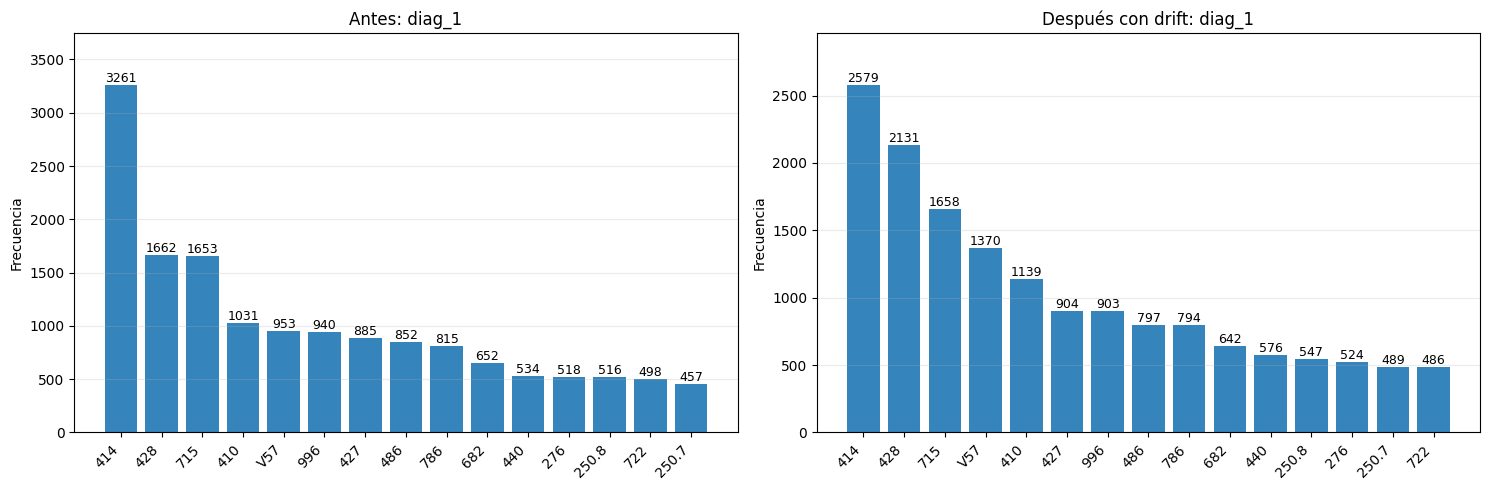

In [22]:
plot_before_after_categorical(
    before=X_train[VARIABLE],
    after=X_train_drift[VARIABLE],
    column=VARIABLE,
    top_n=TOP_N,
    relative=False,
)
plt.show()

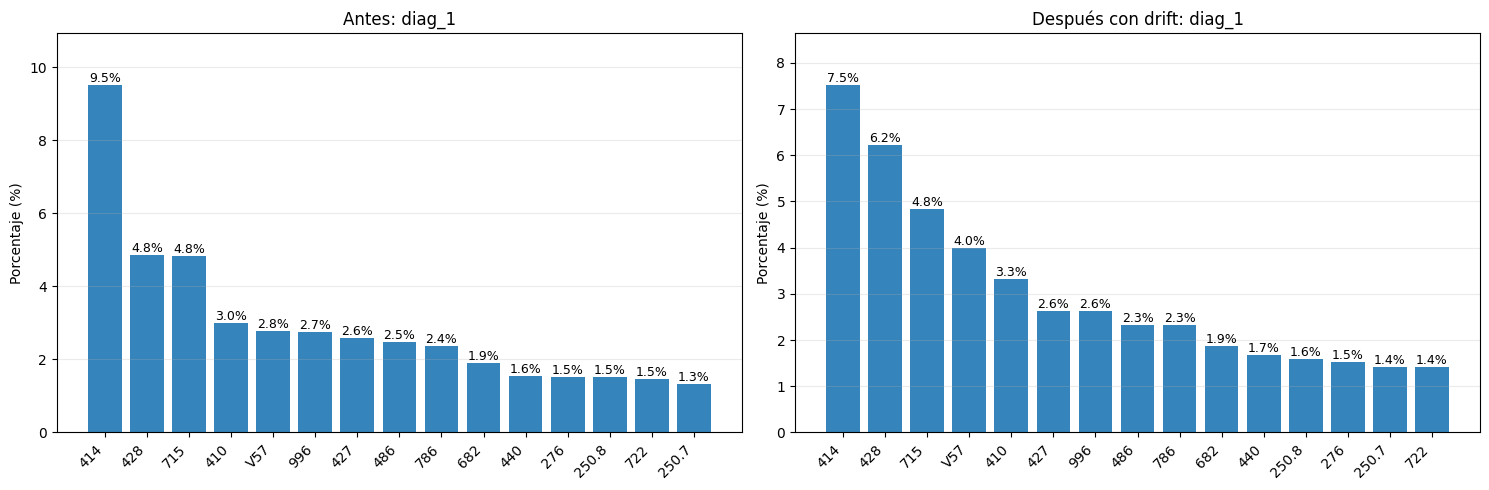

In [23]:
# Mismo gráfico, pero en porcentaje para comparar distribuciones sin depender del tamaño del batch.
plot_before_after_categorical(
    before=X_train[VARIABLE],
    after=X_train_drift[VARIABLE],
    column=VARIABLE,
    top_n=TOP_N,
    relative=True,
)
plt.show()

### 4.1 Antes vs. después en una sola gráfica

Esta visualización coloca ambas distribuciones en el mismo eje para comparar directamente qué diagnósticos suben o bajan después de aplicar el drift.


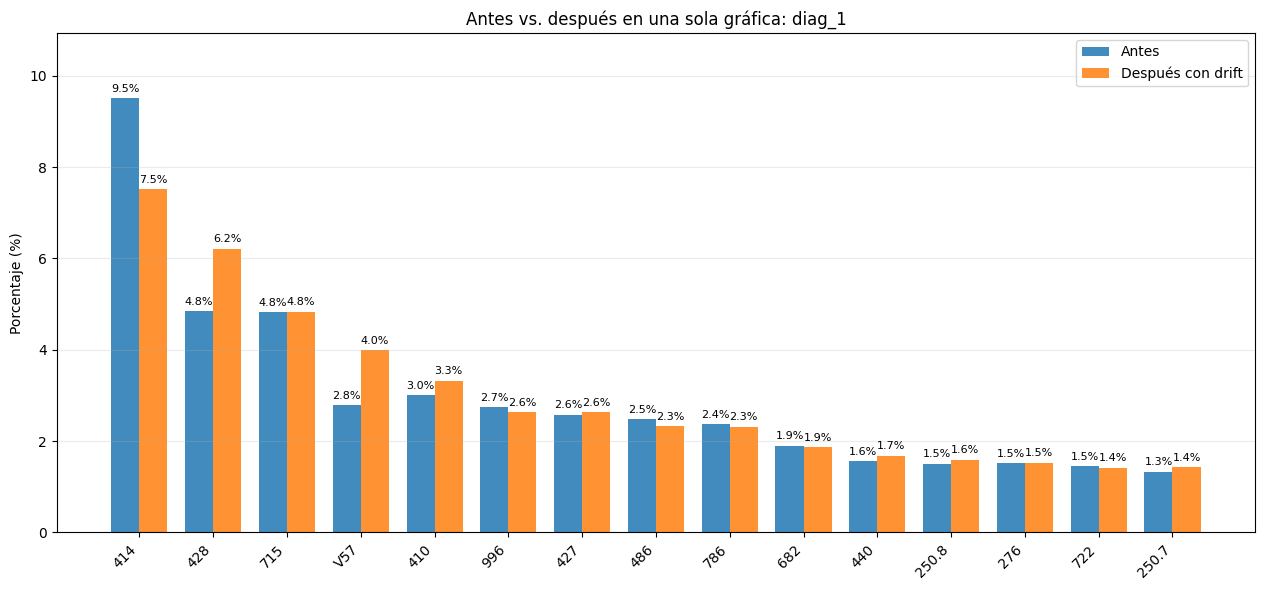

In [24]:
# Gráfico comparativo en una sola figura: antes vs. después.
# Se recomienda usar porcentajes para comparar distribuciones sin depender del tamaño del batch.
plot_overlay_categorical_distributions(
    before=X_train[VARIABLE],
    after=X_train_drift[VARIABLE],
    column=VARIABLE,
    top_n=TOP_N,
    relative=True,
    sort_by="max",
)
plt.show()

### 5. Probar varias severidades

Esta celda genera tres versiones del mismo drift cambiando solo \(\alpha\). Sirve para definir niveles como leve, moderado y severo.


In [53]:
severity_grid = {
    "leve": 0.10,
    "moderado": 0.35,
    "severo": 0.65,
}

drifted_batches = {}

for name, alpha_value in severity_grid.items():
    p_alpha_i = interpolate_distribution(p0, q, alpha_value)

    X_drift_i = sample_rows_with_categorical_drift(
        X_train,
        column=VARIABLE,
        target_p=p_alpha_i,
        reference_p=p0,
        n=len(X_train),
        replace=True,
        random_state=RANDOM_STATE,
    )

    p_after_i = categorical_distribution(X_drift_i[VARIABLE])
    drifted_batches[name] = {
        "alpha": alpha_value,
        "p_alpha": p_alpha_i,
        "X": X_drift_i,
        "p_after": p_after_i,
        "psi": population_stability_index(p0, p_after_i),
        "js": jensen_shannon_divergence(p0, p_after_i),
    }

severity_summary = pd.DataFrame(
    [
        {
            "nivel": name,
            "alpha": values["alpha"],
            "PSI_observado": values["psi"],
            "JS_observado": values["js"],
        }
        for name, values in drifted_batches.items()
    ]
)

display(
    severity_summary.style.format(
        {"alpha": "{:.2f}", "PSI_observado": "{:.4f}", "JS_observado": "{:.6f}"}
    )
)

,nivel,alpha,PSI_observado,JS_observado
0,leve,0.10,0.0205,0.002343
1,moderado,0.35,0.0377,0.004408
2,severo,0.65,0.0613,0.007359


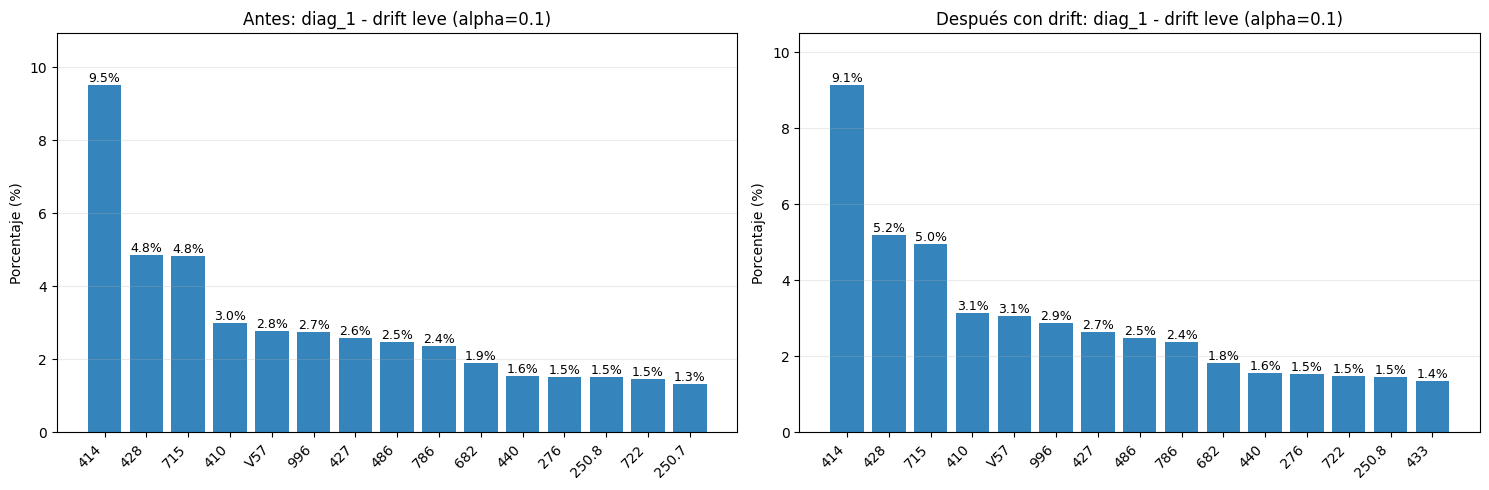

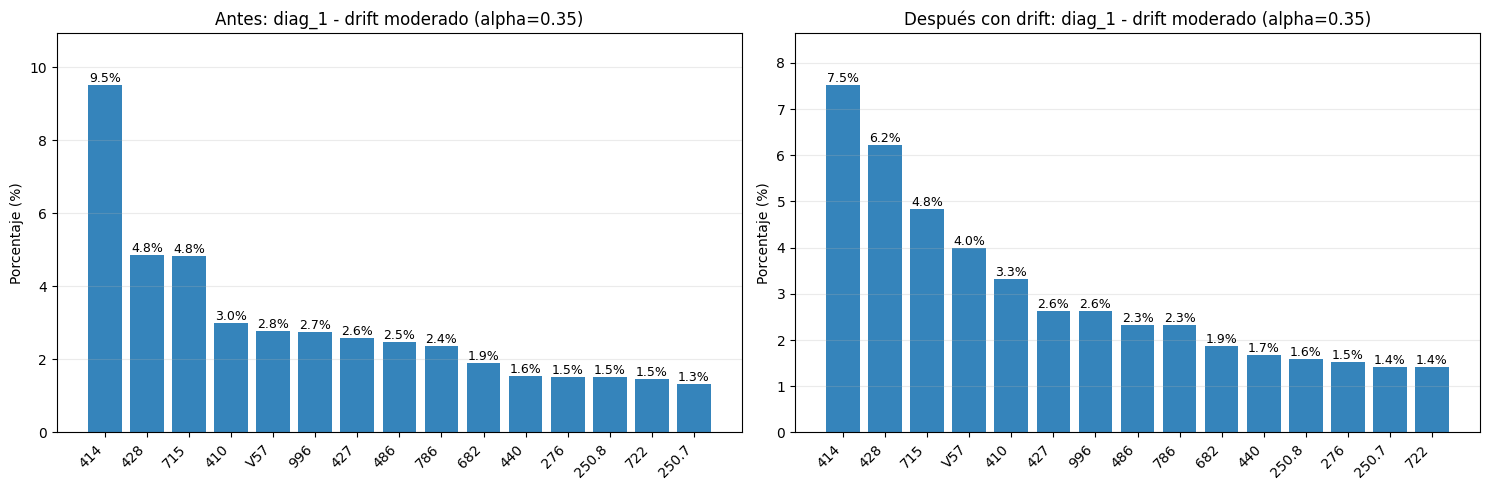

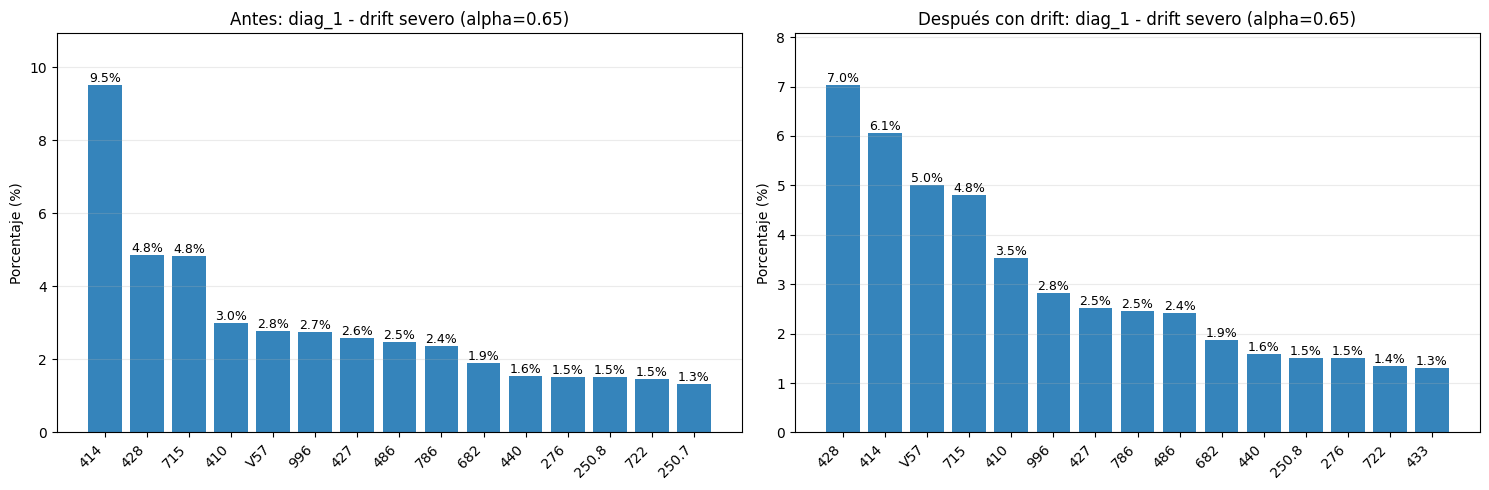

In [26]:
# Visualización rápida de las tres severidades.
for name, values in drifted_batches.items():
    plot_before_after_categorical(
        before=X_train[VARIABLE],
        after=values["X"][VARIABLE],
        column=f"{VARIABLE} - drift {name} (alpha={values['alpha']})",
        top_n=TOP_N,
        relative=True,
    )
    plt.show()

### 5.1 Comparación superpuesta por severidad

Esta celda repite la comparación en una sola gráfica para cada valor de \(\alpha\).


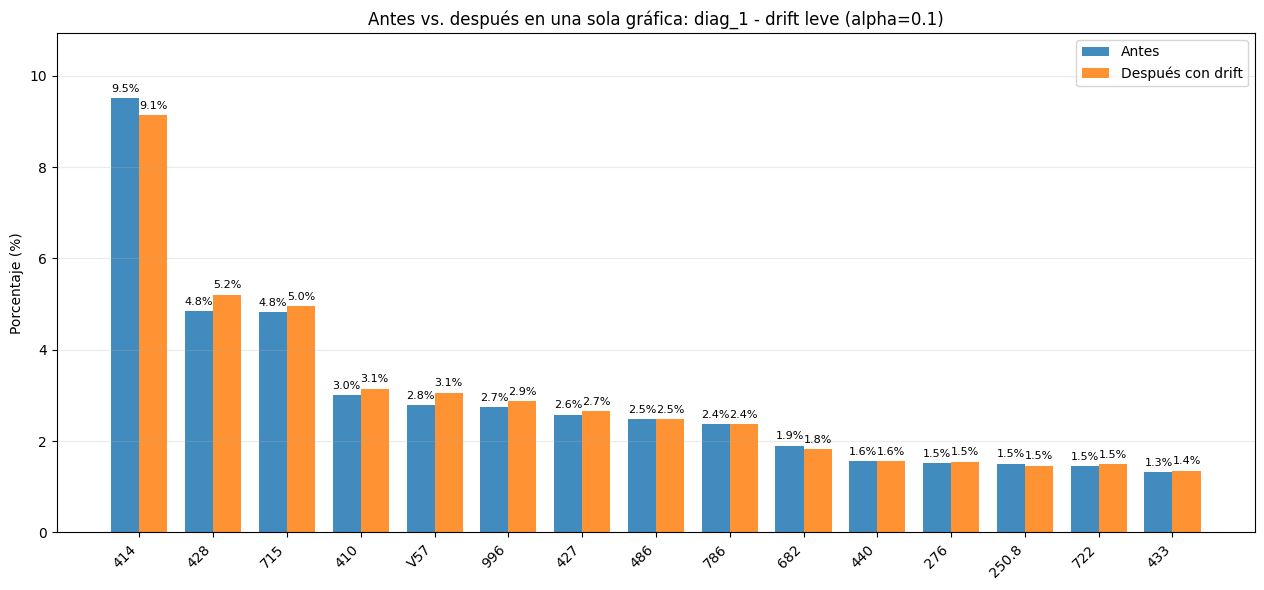

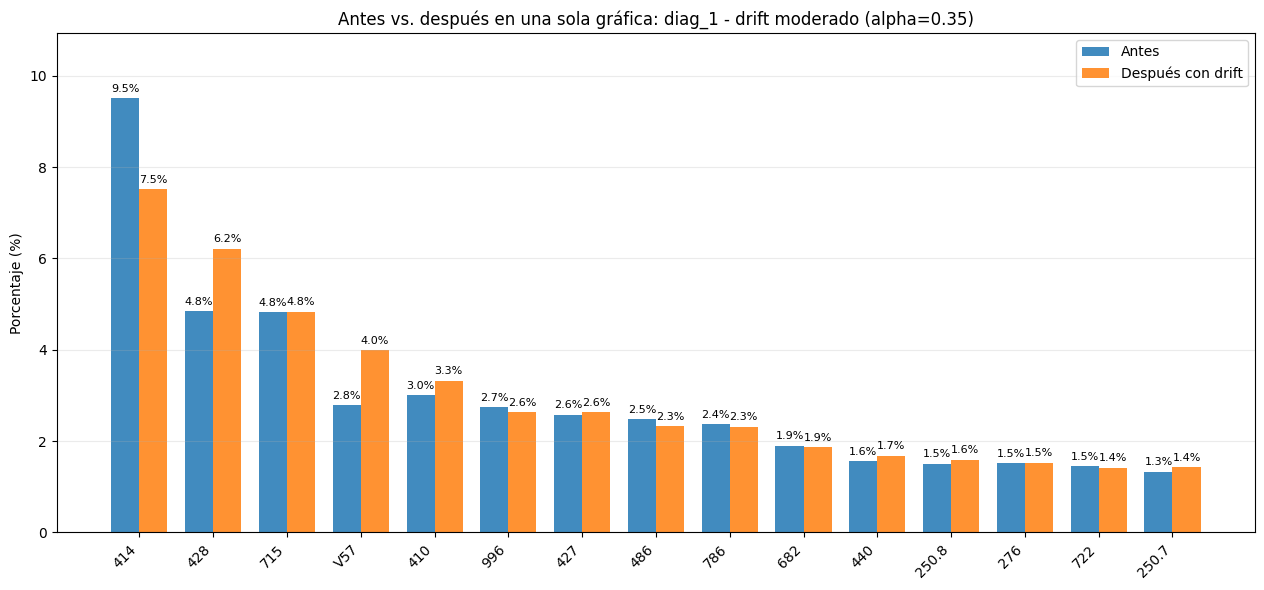

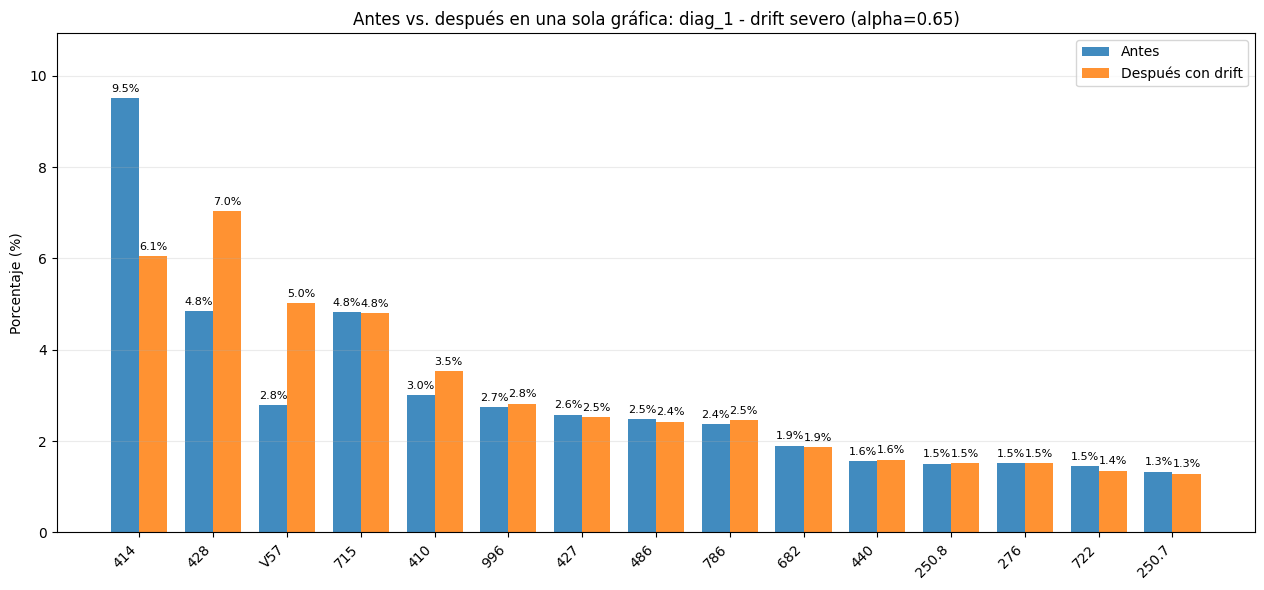

In [54]:
# Comparación en una sola gráfica para cada nivel de severidad.
for name, values in drifted_batches.items():
    plot_overlay_categorical_distributions(
        before=X_train[VARIABLE],
        after=values["X"][VARIABLE],
        column=f"{VARIABLE} - drift {name} (alpha={values['alpha']})",
        top_n=TOP_N,
        relative=True,
        sort_by="max",
    )
    plt.show()

### 6. Guardar el batch con drift

Descomenta esta celda si quieres guardar el dataset drifted para usarlo en el pipeline de monitoreo.


In [ ]:
# output_path = PROJECT_ROOT / "data" / "processed" / f"{VARIABLE}_drift_alpha_{ALPHA:.2f}.csv"
# output_path.parent.mkdir(parents=True, exist_ok=True)
# X_train_drift.to_csv(output_path, index=False)
# print(f"Guardado en: {output_path}")